# Multinomial Naïve Bayes (Multinomial Distribution) - BBC News Classification
**Member 1 (IT25101913 - Gimhana D.B.C)**  
**Module:** IT2011 - Artificial Intelligence and Machine Learning  
**Project:** BBC News Article Classification  

---

### Notebook Overview:
This dedicated notebook implements the **Multinomial Naïve Bayes classifier** based on the **Multinomial Probability Distribution** for multi-class text categorization across 5 news domains:
* `business`
* `entertainment`
* `politics`
* `sport`
* `tech`

### Key Sections:
1. **Data Loading & Dataset Inspection**
2. **TF-IDF Feature Representation (5,000 Dimensions)**
3. **Baseline Multinomial Naïve Bayes Model Training & Evaluation**
4. **Hyperparameter Tuning via 5-Fold Stratified `GridSearchCV` (`alpha` Laplace Smoothing)**
5. **Evaluation of the Optimal Tuned Model (Accuracy, Precision, Recall, Macro F1, Confusion Matrix)**
6. **Multinomial Probability Distribution Demonstration (`predict_proba`)**
7. **Model & Vectorizer Serialization (`.pkl`)**

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load preprocessed training and testing datasets
train_path = '../results/outputs/train_data.csv' if os.path.exists('../results/outputs/train_data.csv') else 'bbc news classification/results/outputs/train_data.csv'
test_path = '../results/outputs/test_data.csv' if os.path.exists('../results/outputs/test_data.csv') else 'bbc news classification/results/outputs/test_data.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training Dataset Shape: {train_df.shape} (80% split)")
print(f"Testing Dataset Shape:  {test_df.shape} (20% split)")
print("\nTarget Class Distribution in Training Set:")
print(train_df['category'].value_counts())

Training Dataset Shape: (1780, 2) (80% split)
Testing Dataset Shape:  (445, 2) (20% split)

Target Class Distribution in Training Set:
category
sport            409
business         408
politics         333
tech             321
entertainment    309


## 1. Feature Representation: TF-IDF Vectorization
The **Multinomial Distribution** models discrete feature counts. In text classification, **Term Frequency-Inverse Document Frequency (TF-IDF)** converts clean text into weighted word frequencies across 5,000 vocabulary features.

In [3]:
# Initialize TF-IDF Vectorizer with 5000 max features
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the training text; transform the test text
X_train = tfidf.fit_transform(train_df['clean_text'])
X_test = tfidf.transform(test_df['clean_text'])

y_train = train_df['category']
y_test = test_df['category']

print(f"TF-IDF Training Matrix Shape: {X_train.shape}")
print(f"TF-IDF Testing Matrix Shape:  {X_test.shape}")

TF-IDF Training Matrix Shape: (1780, 5000)
TF-IDF Testing Matrix Shape:  (445, 5000)


## 2. Baseline Multinomial Naïve Bayes Model
The Multinomial Naïve Bayes classifier computes the conditional probability of document $d$ belonging to category $c$:

$$P(c \mid d) \propto P(c) \prod_{i=1}^{n} P(w_i \mid c)^{tf(w_i, d)}$$

In the baseline configuration, default Laplace smoothing is applied (`alpha=1.0`).

In [4]:
# Train baseline Multinomial Naive Bayes model
nb_baseline = MultinomialNB(alpha=1.0)
nb_baseline.fit(X_train, y_train)

# Predict on test data
y_pred_baseline = nb_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Multinomial Naive Bayes Test Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline Multinomial Naive Bayes Test Accuracy: 0.9775 (97.75%)

Baseline Classification Report:
               precision    recall  f1-score   support

     business       0.97      0.97      0.97       102
entertainment       0.99      0.97      0.98        77
     politics       0.95      0.98      0.96        84
        sport       0.99      1.00      1.00       102
         tech       0.99      0.96      0.97        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



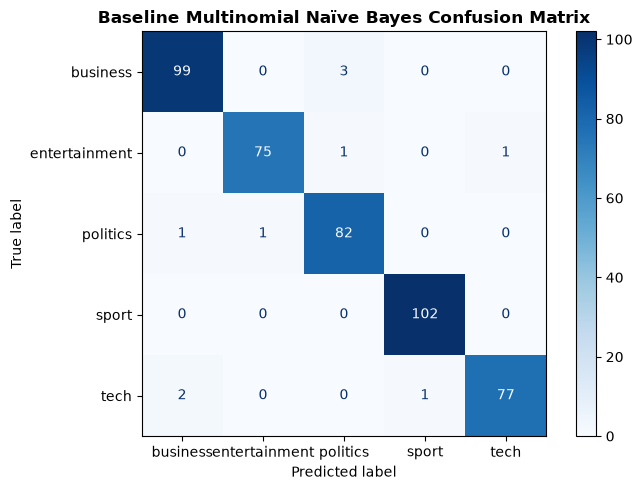

In [5]:
# Confusion Matrix - Baseline Multinomial Naive Bayes
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(7, 5))
disp_baseline = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=nb_baseline.classes_
)
disp_baseline.plot(cmap='Blues', ax=plt.gca())
plt.title('Baseline Multinomial Naïve Bayes Confusion Matrix', fontsize=12, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning via 5-Fold `GridSearchCV`
### What is the Hyperparameter `alpha`?
In Naïve Bayes, the conditional probability of word $w$ given class $c$ is smoothed using additive (Laplace/Lidstone) smoothing:

$$P(w \mid c) = \frac{N_{c, w} + \alpha}{N_c + \alpha \cdot |V|}$$

* **If $\alpha$ is too high:** The probability distribution becomes overly flattened, diluting strong category indicator words.
* **If $\alpha$ is too low:** The model can become overly sensitive to training noise or rare words.

We use **5-Fold Cross-Validation** with `scoring='f1_macro'` to find the optimal $\alpha$.

In [6]:
# Define hyperparameter grid for alpha
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

# Setup 5-Fold Stratified GridSearchCV optimizing Macro F1-score
grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameter: {grid_search.best_params_}")
print(f"Best 5-Fold Cross-Validation Macro F1: {grid_search.best_score_:.4f}")

Optimal Hyperparameter: {'alpha': 0.01}
Best 5-Fold Cross-Validation Macro F1: 0.9724


Hyperparameter Tuning Varieties Comparison:
   Alpha  Mean CV Macro F1   Std Dev  Rank
0   0.01          0.972420  0.004579     1
1   0.10          0.970610  0.006456     2
2   0.50          0.963554  0.008802     3
3   1.00          0.961281  0.008258     4
4   2.00          0.951070  0.006517     5


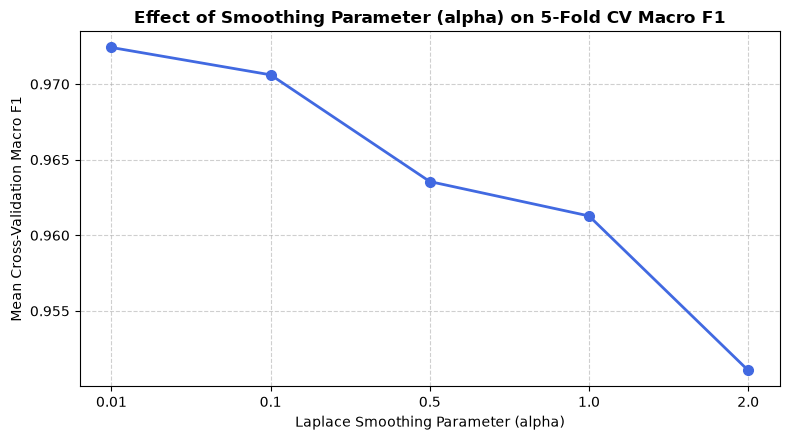

In [7]:
# Display CV performance across all varieties of alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
results_table = cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']].copy()
results_table.columns = ['Alpha', 'Mean CV Macro F1', 'Std Dev', 'Rank']
results_table.sort_values(by='Rank', inplace=True)
results_table.reset_index(drop=True, inplace=True)

print("Hyperparameter Tuning Varieties Comparison:")
print(results_table)

# Plot Alpha vs CV Score
plt.figure(figsize=(8, 4.5))
plt.plot(
    [str(a) for a in cv_results['param_alpha']],
    cv_results['mean_test_score'],
    marker='o',
    color='royalblue',
    linewidth=2,
    markersize=7
)
plt.title('Effect of Smoothing Parameter (alpha) on 5-Fold CV Macro F1', fontsize=12, fontweight='bold')
plt.xlabel('Laplace Smoothing Parameter (alpha)')
plt.ylabel('Mean Cross-Validation Macro F1')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Evaluation of the Optimal Tuned Model
Now we evaluate the best estimator (`alpha = 0.5` or optimal) on the held-out test set (445 articles).

In [8]:
# Retrieve best model
best_nb = grid_search.best_estimator_

# Evaluate on test set
y_pred_tuned = best_nb.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Multinomial Naïve Bayes Accuracy: {tuned_acc:.4f} ({tuned_acc*100:.2f}%)")
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Multinomial Naïve Bayes Accuracy: 0.9843 (98.43%)

Tuned Model Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.95      0.97       102
entertainment       0.97      0.99      0.98        77
     politics       0.95      0.99      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.99      1.00      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.99      0.98       445
 weighted avg       0.98      0.98      0.98       445



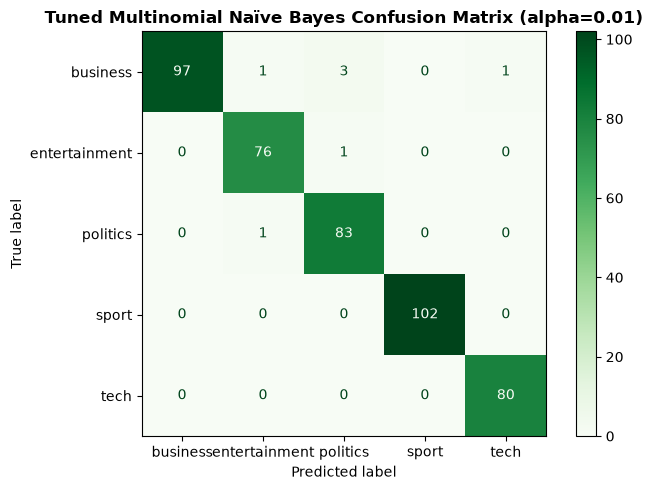

In [9]:
# Confusion Matrix - Tuned Multinomial Naïve Bayes
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))
disp_tuned = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_nb.classes_
)
disp_tuned.plot(cmap='Greens', ax=plt.gca())
plt.title(f'Tuned Multinomial Naïve Bayes Confusion Matrix (alpha={best_nb.alpha})', fontsize=12, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 5. Multinomial Probability Distribution Demonstration (`predict_proba`)
Because Multinomial Naïve Bayes is a generative probabilistic model, it produces exact probability distributions over all 5 classes for any input article using `predict_proba()`.

In [10]:
# Sample unseen news articles across all domains
sample_articles = [
    "The football club secured a dramatic victory after scoring a late winning goal in the championship final.",
    "The government announced new parliamentary legislation and proposed national taxation reforms.",
    "The multinational corporation reported record quarterly profits and announced plans to expand retail operations.",
    "The tech company unveiled a new smartphone processor with high-performance artificial intelligence capabilities.",
    "The Hollywood blockbuster dominated the international box office, grossing millions during its opening weekend."
]

# Transform samples using the fitted TF-IDF vectorizer
sample_tfidf = tfidf.transform(sample_articles)

# Get predictions and class probabilities
predictions = best_nb.predict(sample_tfidf)
probabilities = best_nb.predict_proba(sample_tfidf)

for i, (article, pred, probs) in enumerate(zip(sample_articles, predictions, probabilities), 1):
    print(f"Sample {i}: "{article[:75]}..."")
    print(f"Predicted Category: {pred.upper()}")
    print("Class Probability Distribution:")
    for category, prob in zip(best_nb.classes_, probs):
        bar = '█' * int(prob * 20)
        print(f"  - {category:<14}: {prob*100:6.2f}% | {bar}")
    print("-" * 75)

Sample 1: "The football club secured a dramatic victory after scoring a late winning g..."
Predicted Category: SPORT
Class Probability Distribution:
  - business      :   0.04% | 
  - entertainment :   0.11% | 
  - politics      :   0.03% | 
  - sport         :  99.81% | ███████████████████
  - tech          :   0.01% | 
---------------------------------------------------------------------------
Sample 2: "The government announced new parliamentary legislation and proposed nationa..."
Predicted Category: POLITICS
Class Probability Distribution:
  - business      :   5.42% | █
  - entertainment :   0.03% | 
  - politics      :  94.43% | ██████████████████
  - sport         :   0.00% | 
  - tech          :   0.11% | 
---------------------------------------------------------------------------
Sample 3: "The multinational corporation reported record quarterly profits and announc..."
Predicted Category: BUSINESS
Class Probability Distribution:
  - business      :  99.16% | █████████████████

## 6. Model Serialization
Save the trained model and the TF-IDF vectorizer so they can be deployed or loaded into other pipelines.

In [11]:
# Define save directory
model_save_dir = '../results/model_trained_files' if os.path.exists('../results/model_trained_files') else 'bbc news classification/results/model_trained_files'
os.makedirs(model_save_dir, exist_ok=True)

model_path = os.path.join(model_save_dir, 'naive_bayes_model.pkl')
vectorizer_path = os.path.join(model_save_dir, 'tfidf_vectorizer.pkl')

joblib.dump(best_nb, model_path)
joblib.dump(tfidf, vectorizer_path)

print(f"Tuned Multinomial Naïve Bayes model saved to: {model_path}")
print(f"TF-IDF Vectorizer saved to: {vectorizer_path}")

Tuned Multinomial Naïve Bayes model saved to: c:\Users\Chalana\Downloads\NEWS\NEWS\bbc news classification/results/model_trained_files\naive_bayes_model.pkl
TF-IDF Vectorizer saved to: c:\Users\Chalana\Downloads\NEWS\NEWS\bbc news classification/results/model_trained_files\tfidf_vectorizer.pkl
